In [1]:
# Calculating mortality for the year 2000 to see if it matches GBD 2021

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from utils.mortality_utils import att_frac
from utils.mortality_utils import mortality
from utils.processing_utils import land_filter
from utils.processing_utils import autosize_figure

In [4]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"
MASKS_DIR = "/glade/work/awells/air_quality/BMR/masks/country/"
POP_DIR = "/glade/work/awells/air_quality/SSP_pop/SSP2/"
O3_DIR = "/glade/work/awells/air_quality/O3_obs/"

In [5]:
# === Load data ===
BMR = xr.open_dataarray(f"{BMR_DIR}GBD_BMR_Country_Mask_popgrid_COPD_1990-2009.nc")  # three quantiles
POP = xr.open_dataarray(f"{POP_DIR}ssp2_total_regrid_2000.nc")
o3_2000 = xr.open_dataset(f"{O3_DIR}Delang_BME_OSDMA8_1990_2017.nc")["ozone"].sel(year=slice("1990", "2009")).mean("year")

In [6]:
# === Regrid o3 to match population ===
pop_lat = POP.lat.values
pop_lon = POP.lon.values

o3_lat = o3_2000.latitude.values
o3_lon = o3_2000.longitude.values

# O3 has slightly different lat/lon limits so we want to select the same points
# as the population data
o3_lat_mask = xr.ufuncs.logical_and(o3_lat <= pop_lat.max(), o3_lat >= pop_lat.min())
o3_lon_mask = xr.ufuncs.logical_and(o3_lon <= pop_lon.max(), o3_lon >= pop_lon.min())

# Match dimensions to population exactly
new_o3 = o3_2000.sel(latitude=o3_lat_mask)  # longitudes are the same
o3_interp = new_o3.interp(latitude=POP.lat, longitude=POP.lon, method="linear")

In [7]:
# === Calculate beta for RR GBD 2021 ===

# Relative risk for 10ppb increase in OSDMA8, GBD 2021
RR_10ppb = 1.074  # [95% CI 1.014 – 1.137]
# equation is: RR = e^(beta*(x-TMREL)) where RR_10ppb = e^(10beta)
beta = np.log(RR_10ppb)/10

# TMREL from GBD 2021
TMREL = 32.4  # [95% CI 29.1 – 35.7]

In [8]:
AF = att_frac(o3_interp, TMREL, beta)
M = mortality(AF, BMR, POP)

In [9]:
global_mortality = M.sum(dim=("lat", "lon"))
mean = global_mortality.sel(quantile="mean").round().values
lower = global_mortality.sel(quantile="lower").round().values
upper = global_mortality.sel(quantile="upper").round().values
print(f"Global mortality is {mean} [{lower}, {upper}]")

Global mortality is 303720.0 [265285.0, 338224.0]


In [10]:
# === Calculate total mortality per country ===
masks = xr.open_dataarray(f"{MASKS_DIR}GBD_Country_Masks_0.10_popgrid_newlabels.nc")

# Create DataArray filled with NaNs
global_M_array = xr.DataArray(
    np.full((len(M.lat), len(M.lon)), np.nan),
    coords={"lat": M.lat.values, "lon": M.lon.values},
    dims=["lat", "lon"]
)

# Loop over countries, add the mortality for each country and apply to empty array
for i in range(len(masks.country)):
    mask = masks.isel(country=i)
    country = masks.isel(country=i)["country"]
    M_country = (xr.where(mask == 1, M.sel(quantile="mean"), np.nan)).sum(dim=("lat", "lon"))  # sum of mortality of country (based on BMR)
    global_M_array = global_M_array.where(mask == 0, M_country)

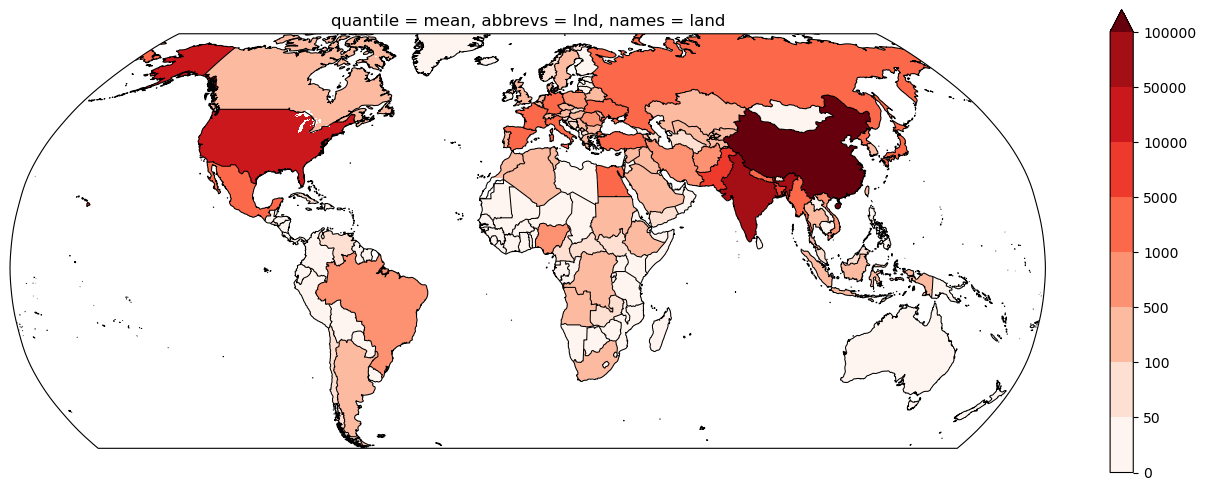

In [11]:
# === Plot country level mortality for year 2000 ===
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=autosize_figure(1, 1, xscale_factor=2))
gs = GridSpec(1, 1)  # rows, columns

projection = ccrs.Robinson()
crs = ccrs.PlateCarree()

col_map = plt.get_cmap('Reds')

country_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_0_boundary_lines_land',
    scale='50m',
    facecolor='none')


# First panel
ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
land_filter(global_M_array).plot(transform=ccrs.PlateCarree(), cmap=col_map, levels=[0, 50, 100, 500, 1000, 5000, 10000, 50000, 100000])
ax.coastlines(resolution="50m", linewidth=0.75)
ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)